# Financial Transaction Fraud Detection — EDA & Data Preparation

**Dataset:** PaySim (synthetic mobile-money transactions)
**Target:** `isFraud` (1 = fraud)

This notebook covers: business understanding, data exploration, quality checks, EDA, and feature engineering setup.

## 1. Setup & Load

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/fraud_0.1origbase.csv")
df.shape

(636262, 11)

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,283,CASH_IN,210329.84,C1159819632,3778062.79,3988392.64,C1218876138,1519266.60,1308936.76,0,0
1,132,CASH_OUT,215489.19,C1372369468,21518.00,0.00,C467105520,6345756.55,6794954.89,0,0
2,355,DEBIT,4431.05,C1059822709,20674.00,16242.95,C76588246,80876.56,85307.61,0,0
3,135,CASH_OUT,214026.20,C1464960643,46909.73,0.00,C1059379810,13467450.36,13681476.56,0,0
4,381,CASH_OUT,8858.45,C831134427,0.00,0.00,C579876929,1667180.58,1676039.03,0,0


## 2. Business Understanding

Fraud is **rare but costly**. We must catch fraud (high recall) without flooding analysts with false alarms (reasonable precision). Accuracy is a *trap* here — see below.

In [8]:
fraud_rate = df['isFraud'].mean()
print(f"Fraud cases : {df['isFraud'].sum():,}")
print(f"Total       : {len(df):,}")
print(f"Fraud rate  : {fraud_rate*100:.4f}%")
print(f"\nA 'predict never-fraud' model would score {(1-fraud_rate)*100:.2f}% accuracy — and catch ZERO fraud.")

Fraud cases : 821
Total       : 636,262
Fraud rate  : 0.1290%

A 'predict never-fraud' model would score 99.87% accuracy — and catch ZERO fraud.


## 3. Data Quality Checks
Missing values, duplicates, data types.

In [9]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0

Data types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


## 4. Key Finding — Fraud Only Occurs in CASH_OUT & TRANSFER

This is the single most important insight. It justifies filtering the data to these two types.

In [10]:
by_type = df.groupby('type')['isFraud'].agg(count='count', fraud='sum', rate='mean')
by_type['rate_%'] = (by_type['rate']*100).round(4)
by_type

,count,fraud,rate,rate_%
type,,,,
CASH_IN,139614,0,0.000000,0.0000
CASH_OUT,224216,407,0.001815,0.1815
DEBIT,4170,0,0.000000,0.0000
PAYMENT,214968,0,0.000000,0.0000
TRANSFER,53294,414,0.007768,0.7768


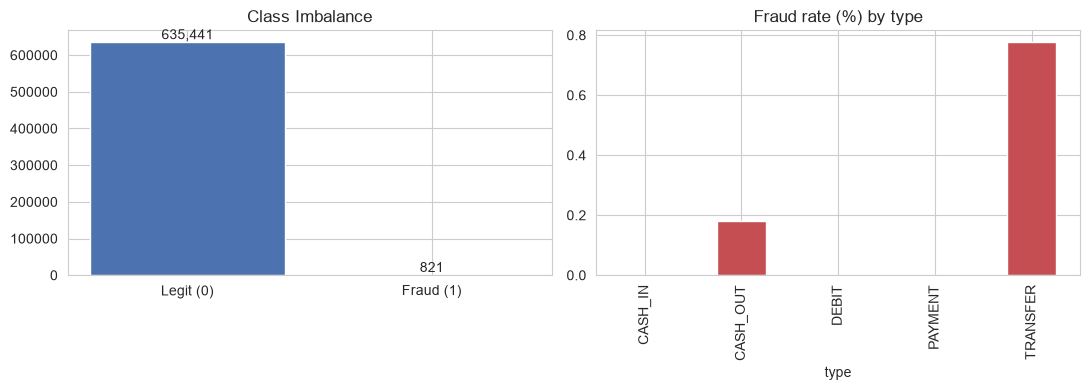

In [11]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
vc = df['isFraud'].value_counts()
ax[0].bar(['Legit (0)','Fraud (1)'], vc.values, color=['#4C72B0','#C44E52'])
ax[0].set_title('Class Imbalance'); 
for i,v in enumerate(vc.values): ax[0].text(i, v, f"{v:,}", ha='center', va='bottom')
(df.groupby('type')['isFraud'].mean()*100).plot(kind='bar', ax=ax[1], color='#C44E52')
ax[1].set_title('Fraud rate (%) by type'); plt.tight_layout(); plt.show()

## 5. Filter to Fraud-Capable Types
Drop CASH_IN, PAYMENT, DEBIT (0% fraud). Effective fraud rate roughly doubles.

In [12]:
d = df[df['type'].isin(['CASH_OUT','TRANSFER'])].copy()
print("Rows after filter:", len(d))
print(f"New fraud rate   : {d['isFraud'].mean()*100:.4f}%")

Rows after filter: 277510
New fraud rate   : 0.2958%


## 6. Feature Engineering — Balance Error Terms
If accounting is honest, balances reconcile. Fraud often breaks the math.

In [13]:
d['errorBalanceOrig'] = d['oldbalanceOrg'] - d['amount'] - d['newbalanceOrig']
d['errorBalanceDest'] = d['oldbalanceDest'] + d['amount'] - d['newbalanceDest']

# Full-drain flag: fraud almost always empties the sender's account
d['isFullDrain'] = np.isclose(d['amount'], d['oldbalanceOrg']).astype(int)

d.groupby('isFraud')[['amount','errorBalanceOrig','errorBalanceDest','isFullDrain']].median()

,amount,errorBalanceOrig,errorBalanceDest,isFullDrain
isFraud,,,,
0,170997.65,-143876.77,0.0,0.0
1,404394.04,0.00,4232.0,1.0


### The strongest single signal: account drain

In [14]:
drain = d.groupby('isFraud')['isFullDrain'].mean()*100
print(drain)
# ~98% of fraud drains the account vs ~0% of legit transactions

isFraud
0     0.000000
1    97.929354
Name: isFullDrain, dtype: float64


## 7. Amount Distribution
Fraud skews to larger amounts.

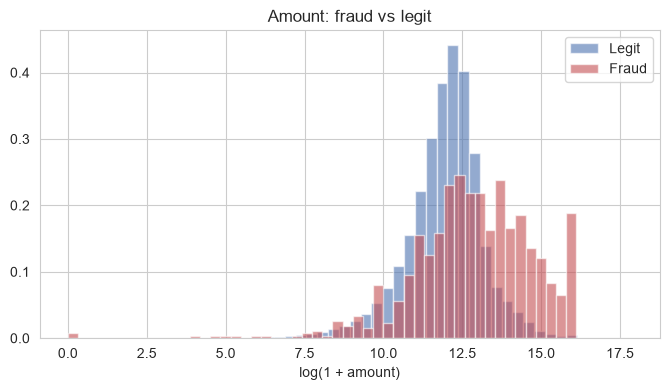

In [15]:
fig, ax = plt.subplots(figsize=(8,4))
for label,c,n in [(0,'#4C72B0','Legit'),(1,'#C44E52','Fraud')]:
    ax.hist(np.log1p(d[d['isFraud']==label]['amount']), bins=50, alpha=0.6, label=n, color=c, density=True)
ax.set_xlabel('log(1 + amount)'); ax.legend(); ax.set_title('Amount: fraud vs legit'); plt.show()

## 8. Correlation Heatmap

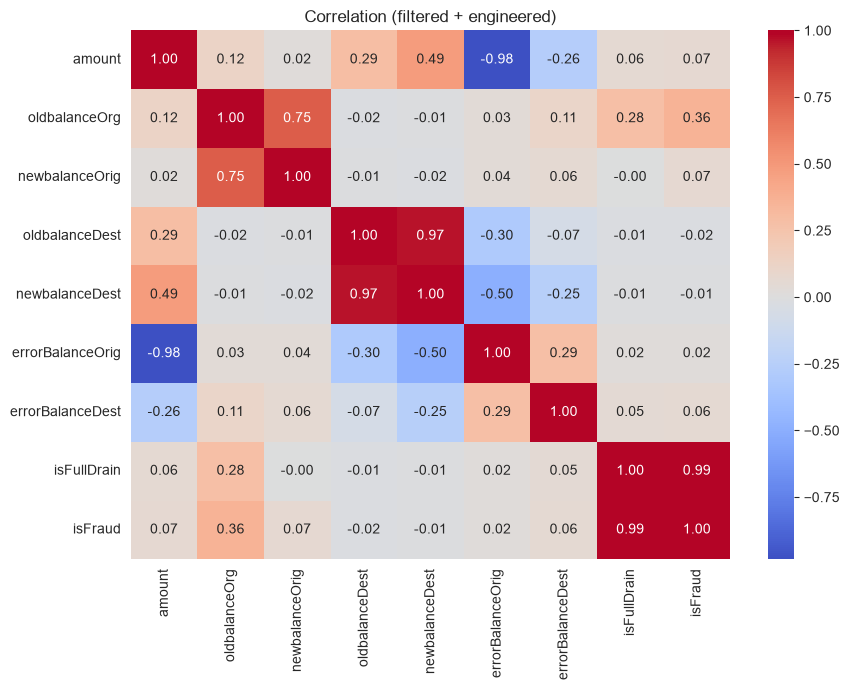

In [16]:
num = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',
       'errorBalanceOrig','errorBalanceDest','isFullDrain','isFraud']
plt.figure(figsize=(9,7))
sns.heatmap(d[num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation (filtered + engineered)'); plt.tight_layout(); plt.show()

## 9. Save Processed Data
Drop ID columns and the useless flag. Ready for modeling.

In [17]:
d = d.drop(columns=['nameOrig','nameDest','isFlaggedFraud'])
d.to_csv("../data/processed/fraud_processed.csv", index=False)
print("Saved:", d.shape)
d.head()

Saved: (277510, 11)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,isFullDrain
1,132,CASH_OUT,215489.19,21518.00,0.0,6345756.55,6794954.89,0,-193971.19,-2.337091e+05,0
3,135,CASH_OUT,214026.20,46909.73,0.0,13467450.36,13681476.56,0,-167116.47,-1.862645e-09,0
4,381,CASH_OUT,8858.45,0.00,0.0,1667180.58,1676039.03,0,-8858.45,0.000000e+00,0
6,347,CASH_OUT,120989.98,0.00,0.0,6963396.37,7084386.35,0,-120989.98,9.313226e-10,0
7,183,CASH_OUT,62655.01,18997.00,0.0,130706.17,193361.18,0,-43658.01,0.000000e+00,0


## 10. EDA Summary — Key Takeaways

1. **Severe imbalance** — 0.13% fraud → use Precision/Recall/F1/PR-AUC, never accuracy.
2. **Fraud only in CASH_OUT & TRANSFER** → filtered, doubling effective fraud rate.
3. **Account drain is the dominant signal** — ~98% of fraud empties the sender's balance.
4. **Fraud amounts are larger** (median ~2.4× legit).
5. **Engineered `errorBalance` + `isFullDrain`** features expose fraud the raw columns hide.

**Next:** preprocessing → train/test split (before resampling) → baseline models → evaluation.